# 06 - Between-cancer geometry in latent space (refactored)

## Purpose

Notebook 5 quantified **within-comparison latent complexity** for matched normal–tumor pairs.  
This Notebook 6 examines **between-cancer geometry** in the same latent space.

The notebook follows the **actual conventions used in the current working Notebook 5**:

- latent source: `data/processed/latent.npy`
- metadata source: `data/inputs/hu35ksuba_metadata.csv`
- Notebook 5 handoff: `output/tables/latent/latent_comparison_metrics.csv`

## Design goals

1. Use the same metadata-loading logic and column conventions as Notebook 5.
2. Keep the core geometry analysis independent of Notebook 5 outputs.
3. Make the Notebook 5 handoff **optional** and explicit.
4. Default to a biologically cleaner mode: **cancer-only groups**, grouped by `disease_clean`.

You can later switch the scope to include normal tissues or use `tissue_label` instead.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist, squareform
from scipy.stats import spearmanr

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False

try:
    import plotly.express as px
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

print("Libraries loaded.")
print("seaborn :", HAS_SNS)
print("umap    :", HAS_UMAP)
print("networkx:", HAS_NX)
print("plotly  :", HAS_PLOTLY)


Libraries loaded.
seaborn : True
umap    : True
networkx: True
plotly  : True


In [2]:
%run ./00_latent_space_config.ipynb

OUTPUT_DIR = PROJECT_DIR / "output"

TABLES_DIR = OUTPUT_DIR / "tables"
LATENT_TABLES_DIR = TABLES_DIR / "latent"

PLOTS_DIR = OUTPUT_DIR / "plots"
LATENT_PLOTS_DIR = PLOTS_DIR / "latent"

# Notebook-specific output locations
NB6_TABLE_DIR = LATENT_TABLES_DIR / "notebook_06"
NB6_PLOT_DIR = LATENT_PLOTS_DIR / "notebook_06"

GLOBAL_CANCER_DIR = PROJECT_DIR / "output" / "global_cancer" / "reports"

NB6_TABLE_DIR.mkdir(parents=True, exist_ok=True)
NB6_PLOT_DIR.mkdir(parents=True, exist_ok=True)

latent_path = LATENT_PATH
metadata_path = METADATA_ALIGNED_PATH

entropy_overlay_path = GLOBAL_CANCER_DIR / "entropy_cleaned.csv"
complexity_overlay_path = GLOBAL_CANCER_DIR / "complexity_cleaned.csv"

if not entropy_overlay_path.exists():
    entropy_overlay_path = PROJECT_DIR / "entropy_cleaned.csv"

if not complexity_overlay_path.exists():
    complexity_overlay_path = PROJECT_DIR / "complexity_cleaned.csv"

print("PROJECT_DIR            :", PROJECT_DIR)
print("latent_path            :", latent_path)
print("metadata_path          :", metadata_path)
print("entropy_overlay_path   :", entropy_overlay_path)
print("complexity_overlay_path:", complexity_overlay_path)
print("NB6_TABLE_DIR          :", NB6_TABLE_DIR)
print("NB6_PLOT_DIR           :", NB6_PLOT_DIR)

Notebook directory : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\notebooks
Project directory  : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity
ML input directory : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed\ml_inputs
Processed directory: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed
Output directory   : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\global_cancer
Expression path: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\processed\ml_inputs\hu35ksuba_expr_top3000_variance.csv | exists: True
Metadata path  : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\data\global_cancer\p

## Load latent coordinates and metadata

This cell mirrors Notebook 5 directly, including the required metadata columns and the row-order join.

In [3]:
if not latent_path.exists():
    raise FileNotFoundError(f"Missing latent file: {latent_path}")
if not metadata_path.exists():
    raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

latent = np.load(latent_path)
metadata = load_metadata(metadata_path=metadata_path, require_full_contract=True)

required_cols = [
    "sample_id",
    "geo_accession",
    "title",
    "platform_id",
    "disease_clean",
    "tissue_clean",
    "condition",
    "tissue_label",
]
missing = [c for c in required_cols if c not in metadata.columns]
if missing:
    raise KeyError(f"Missing required metadata columns: {missing}")

if latent.shape[0] != metadata.shape[0]:
    raise ValueError(
        f"Row mismatch: latent has {latent.shape[0]} rows but metadata has {metadata.shape[0]} rows."
    )

latent_df = pd.DataFrame(latent, index=metadata.index)
latent_df.columns = [f"z{i+1}" for i in range(latent_df.shape[1])]

df = latent_df.join(metadata)

print("latent shape  :", latent.shape)
print("metadata shape:", metadata.shape)
print("df shape      :", df.shape)
display(df.head())

latent shape  : (278, 10)
metadata shape: (278, 43)
df shape      : (278, 53)


,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,sample_id,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,characteristics_ch1,characteristics_ch1.1,molecule_ch1,extract_protocol_ch1,label_ch1,label_protocol_ch1,taxid_ch1,hyb_protocol,scan_protocol,description,data_processing,platform_id,contact_name,contact_email,contact_phone,contact_department,contact_institute,contact_address,contact_city,contact_state,contact_zip/postal_code,contact_country,supplementary_file,supplementary_file.1,supplementary_file.2,supplementary_file.3,data_row_count,disease state:ch1,organism part:ch1,condition,tissue_label,disease_clean,tissue_clean
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GSM1686773_CL2000062805AA.CEL,-0.891098,5.696705,-4.469275,7.692773,8.939398,0.992899,-1.079474,13.861112,-3.514981,4.776511,GSM1686773_CL2000062805AA.CEL,golub-00236: CL2000062805AA,GSM1686773,Public on May 16 2015,May 15 2015,May 16 2015,RNA,1,prostate adenocarcinoma,Homo sapiens,disease state: prostate adenocarcinoma,organism part: Prostate,total RNA,See mage-tab files linked to series entry for ...,biotin,See mage-tab files linked to series entry for ...,9606,See mage-tab files linked to series entry for ...,See mage-tab files linked to series entry for ...,Prostate__Adeno_LocalCaP1T,See mage-tab files linked to series entry for ...,GPL98,"Mervi,,Heiskanen",mervi.heiskanen@nih.gov,2402765175,CBIIT,NCI,"9609 Medical Center Drive, 1W378",Rockville,MD,20850,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,0,prostate adenocarcinoma,Prostate,cancer,prostate_prostate.adenocarcinoma,prostate adenocarcinoma,Prostate
GSM1686774_CL2000062807AA.CEL,7.145813,3.601434,2.103221,6.663136,4.724164,-5.885802,-0.047318,15.595482,-6.074564,2.251225,GSM1686774_CL2000062807AA.CEL,golub-00236: CL2000062807AA,GSM1686774,Public on May 16 2015,May 15 2015,May 16 2015,RNA,1,prostate adenocarcinoma,Homo sapiens,disease state: prostate adenocarcinoma,organism part: Prostate,total RNA,See mage-tab files linked to series entry for ...,biotin,See mage-tab files linked to series entry for ...,9606,See mage-tab files linked to series entry for ...,See mage-tab files linked to series entry for ...,Prostate__Adeno_LocalCaP10T,See mage-tab files linked to series entry for ...,GPL98,"Mervi,,Heiskanen",mervi.heiskanen@nih.gov,2402765175,CBIIT,NCI,"9609 Medical Center Drive, 1W378",Rockville,MD,20850,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,0,prostate adenocarcinoma,Prostate,cancer,prostate_prostate.adenocarcinoma,prostate adenocarcinoma,Prostate
GSM1686775_CL2000062808AA.CEL,1.750058,5.659782,-0.274540,9.270736,7.250854,0.176477,-0.933469,14.510089,-3.529614,5.140491,GSM1686775_CL2000062808AA.CEL,golub-00236: CL2000062808AA,GSM1686775,Public on May 16 2015,May 15 2015,May 16 2015,RNA,1,normal Prostate,Homo sapiens,disease state: normal,organism part: Prostate,total RNA,See mage-tab files linked to series entry for ...,biotin,See mage-tab files linked to series entry for ...,9606,See mage-tab files linked to series entry for ...,See mage-tab files linked to series entry for ...,Normal__Prostate_NLP10N,See mage-tab files linked to series entry for ...,GPL98,"Mervi,,Heiskanen",mervi.heiskanen@nih.gov,2402765175,CBIIT,NCI,"9609 Medical Center Drive, 1W378",Rockville,MD,20850,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1686...,0,normal,Prostate,normal,prostate,normal,Prostate
GSM1686789_CL2000071829AA.CEL,11.663876,6.399312,-11.456659,12.533592,10.969925,3.032189,-8.057707,-2.554

## Analysis settings

Defaults are set for **between-cancer** analysis rather than mixed normal–tumor analysis.

- `ANALYSIS_SCOPE = "cancer_only"` keeps only tumor samples.
- `GROUPING = "disease"` compares cancers by `disease_clean`.

Allowed values:

- `ANALYSIS_SCOPE`: `"cancer_only"` or `"all_samples"`
- `GROUPING`: `"disease"`, `"tissue"`, or `"tissue_label"`

In [4]:
ANALYSIS_SCOPE = "cancer_only"
GROUPING = "disease"
MIN_SAMPLES_PER_GROUP = 8
K_NEIGHBORS = 10
N_GRAPH_NEIGHBORS = 2
GRAPH_EDGE_DISTANCE_QUANTILE = 0.35
SHOW_INTERACTIVE_PLOTLY = True

latent_cols = [c for c in df.columns if c.startswith("z")]

work = df[
    [
        "sample_id",
        "geo_accession",
        "title",
        "platform_id",
        "tissue_clean",
        "disease_clean",
        "condition",
        "tissue_label",
    ] + latent_cols
].copy()

work["sample_id"] = work["sample_id"].astype(str).str.strip()
work["geo_accession"] = work["geo_accession"].astype(str).str.strip()
work["tissue"] = work["tissue_clean"].astype(str).str.strip()
work["disease"] = work["disease_clean"].astype(str).str.strip()
work["state"] = work["condition"].astype(str).str.strip()
work["tissue_label"] = work["tissue_label"].astype(str).str.strip()

if ANALYSIS_SCOPE == "cancer_only":
    analysis_pool = work.loc[work["state"] == "cancer"].copy()
elif ANALYSIS_SCOPE == "all_samples":
    analysis_pool = work.copy()
else:
    raise ValueError("ANALYSIS_SCOPE must be 'cancer_only' or 'all_samples'.")

group_col_map = {
    "disease": "disease",
    "tissue": "tissue",
    "tissue_label": "tissue_label",
}
if GROUPING not in group_col_map:
    raise ValueError("GROUPING must be one of: 'disease', 'tissue', 'tissue_label'.")

group_source_col = group_col_map[GROUPING]
analysis_pool["group_label"] = analysis_pool[group_source_col].astype(str).str.strip()

analysis_pool = analysis_pool.replace({"group_label": {"nan": np.nan, "": np.nan}})
analysis_pool = analysis_pool.dropna(subset=["group_label"] + latent_cols).reset_index(drop=True)

group_counts = analysis_pool["group_label"].value_counts()
valid_groups = group_counts[group_counts >= MIN_SAMPLES_PER_GROUP].index

analysis_df = (
    analysis_pool.loc[analysis_pool["group_label"].isin(valid_groups)].copy().reset_index(drop=True)
)

SUPERCLASS_MAP = {
    "B-cell ALL": "hematologic",
    "T-cell ALL": "hematologic",
    "acute myeloid leukemia": "hematologic",
    "large B-cell lymphoma": "hematologic",
    "Follicular lymphoma": "hematologic",
    "glioblastoma": "CNS",
    "medulloblastoma": "CNS",
    "breast adenocarcinoma": "epithelial",
    "lung adenocarcinoma": "epithelial",
    "colorectal adenocarcinoma": "epithelial",
    "pancreatic adenocarcinoma": "epithelial",
    "ovarian adenocarcinoma": "epithelial",
    "uterine adenocarcinoma": "epithelial",
    "prostate adenocarcinoma": "epithelial",
    "renal cell carcinoma": "urologic",
    "bladder transitional cell carcinoma": "urologic",
    "melanoma": "melanocytic",
    "mesothelioma": "mesothelial",
}

SUPERCLASS_COLORS = {
    "hematologic": "#d62728",
    "CNS": "#9467bd",
    "epithelial": "#1f77b4",
    "urologic": "#2ca02c",
    "melanocytic": "#ff7f0e",
    "mesothelial": "#8c564b",
    "other": "#7f7f7f",
}

# Dissertation-style short comparison codes.
# These are the codes needed downstream for joining to the R postprocessing outputs.
COMPARISON_CODE_MAP = {
    "bladder transitional cell carcinoma": "BLAD/TCC",
    "breast adenocarcinoma": "BR/BRAD",
    "glioblastoma": "Brain/GBM",
    "medulloblastoma": "Brain/MB",
    "colorectal adenocarcinoma": "COL/COADREAD",
    "Follicular lymphoma": "GC/FL",
    "large B-cell lymphoma": "GC/LBCL",
    "renal cell carcinoma": "KID/RCC",
    "lung adenocarcinoma": "LU/LUAD",
    "ovarian adenocarcinoma": "OV/OVAD",
    "pancreatic adenocarcinoma": "PA/PAAD",
    "B-cell ALL": "PB/B-ALL",
    "T-cell ALL": "PB/T-ALL",
    "prostate adenocarcinoma": "PR/PRAD",
    "uterine adenocarcinoma": "UT/EAC",
}

analysis_df["superclass"] = analysis_df["group_label"].map(SUPERCLASS_MAP).fillna("other")

print("ANALYSIS_SCOPE:", ANALYSIS_SCOPE)
print("GROUPING      :", GROUPING)
print("analysis_df shape:", analysis_df.shape)
print("number of retained groups:", analysis_df["group_label"].nunique())

display(
    analysis_df.groupby(["group_label", "superclass"])
    .size()
    .reset_index(name="n_samples")
    .sort_values(["superclass", "n_samples", "group_label"], ascending=[True, False, True])
)

ANALYSIS_SCOPE: cancer_only
GROUPING      : disease
analysis_df shape: (187, 23)
number of retained groups: 18


,group_label,superclass,n_samples
7,glioblastoma,CNS,10
10,medulloblastoma,CNS,10
5,breast adenocarcinoma,epithelial,11
6,colorectal adenocarcinoma,epithelial,11
9,lung adenocarcinoma,epithelial,11
13,ovarian adenocarcinoma,epithelial,11
14,pancreatic adenocarcinoma,epithelial,10
15,prostate adenocarcinoma,epithelial,10
17,uterine adenocarcinoma,epithelial,10
1,Follicular lymphoma,hematologic,11


## Helper functions

In [5]:
def compute_centroids(df, group_col, latent_cols):
    return df.groupby(group_col)[latent_cols].mean()

def compute_group_dispersion(df, group_col, latent_cols):
    rows = []
    for group_name, sub in df.groupby(group_col):
        X = sub[latent_cols].to_numpy(dtype=float)
        centroid = X.mean(axis=0)
        dists = np.linalg.norm(X - centroid, axis=1)
        rows.append(
            {
                group_col: group_name,
                "n_samples": len(sub),
                "mean_radius": float(np.mean(dists)),
                "median_radius": float(np.median(dists)),
                "rms_radius": float(np.sqrt(np.mean(dists ** 2))),
                "std_radius": float(np.std(dists)),
            }
        )
    return pd.DataFrame(rows)

def pairwise_distance_df(X_df, metric="euclidean"):
    D = cdist(X_df.values, X_df.values, metric=metric)
    return pd.DataFrame(D, index=X_df.index, columns=X_df.index)

def upper_triangle_pairs(dist_df, value_col, row_name="group_a", col_name="group_b"):
    rows = []
    labels = list(dist_df.index)
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            rows.append(
                {
                    row_name: labels[i],
                    col_name: labels[j],
                    value_col: dist_df.iloc[i, j],
                }
            )
    return pd.DataFrame(rows)

def compute_normalized_separation(centroids_df, dispersion_df, group_col, radius_col="rms_radius"):
    radii = dispersion_df.set_index(group_col)[radius_col]
    labels = list(centroids_df.index)
    M = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for a in labels:
        for b in labels:
            d = np.linalg.norm(centroids_df.loc[a].values - centroids_df.loc[b].values)
            denom = radii.loc[a] + radii.loc[b]
            M.loc[a, b] = np.nan if denom == 0 else d / denom
    return M

def compute_knn_mixing(df, group_col, latent_cols, k=10, sample_id_col="sample_id"):
    if len(df) < 2:
        raise ValueError("Need at least 2 samples for kNN mixing.")
    k_eff = min(k, len(df) - 1)
    X = df[latent_cols].to_numpy(dtype=float)
    y = df[group_col].to_numpy()
    nn = NearestNeighbors(n_neighbors=k_eff + 1)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)
    indices = indices[:, 1:]
    rows = []
    for i in range(len(df)):
        neigh_labels = y[indices[i]]
        same_frac = np.mean(neigh_labels == y[i])
        rows.append(
            {
                sample_id_col: df.iloc[i][sample_id_col],
                group_col: y[i],
                "same_group_neighbor_fraction": float(same_frac),
            }
        )
    sample_knn_df = pd.DataFrame(rows)
    return sample_knn_df, indices, k_eff

def compute_pairwise_mixing_matrix(df, group_col, indices):
    y = df[group_col].to_numpy()
    labels = sorted(pd.unique(y))
    M = pd.DataFrame(0.0, index=labels, columns=labels)
    for i in range(len(df)):
        src = y[i]
        neigh_labels = y[indices[i]]
        counts = pd.Series(neigh_labels).value_counts(normalize=True)
        for tgt, frac in counts.items():
            M.loc[src, tgt] += frac
    src_counts = df[group_col].value_counts()
    for src in labels:
        M.loc[src] = M.loc[src] / src_counts.loc[src]
    return M

def compute_group_silhouette(df, group_col, latent_cols, sample_id_col="sample_id"):
    if df[group_col].nunique() < 2:
        raise ValueError("Silhouette requires at least 2 groups.")
    X = df[latent_cols].to_numpy(dtype=float)
    y = df[group_col].to_numpy()
    sample_sil = silhouette_samples(X, y, metric="euclidean")
    global_sil = silhouette_score(X, y, metric="euclidean")
    sample_df = df[[sample_id_col, group_col]].copy()
    sample_df["silhouette"] = sample_sil
    group_df = (
        sample_df.groupby(group_col)["silhouette"]
        .agg(["mean", "median", "std", "count"])
        .reset_index()
        .rename(
            columns={
                "mean": "mean_silhouette",
                "median": "median_silhouette",
                "std": "std_silhouette",
                "count": "n_samples",
            }
        )
    )
    return sample_df, group_df, global_sil

def classify_separation(mean_silhouette, same_group_fraction):
    if pd.isna(mean_silhouette) or pd.isna(same_group_fraction):
        return "unclassified"
    if mean_silhouette >= 0.12 and same_group_fraction >= 0.45:
        return "high separation"
    if mean_silhouette <= -0.05 or same_group_fraction <= 0.20:
        return "low separation"
    return "moderate separation"

def standardize_comparison_slice(df):
    if df is None or df.empty:
        return df
    out = df.copy()
    if "comparison" in out.columns:
        out["comparison"] = out["comparison"].astype(str).str.strip()
    return out

def load_overlay_csv(path):
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded overlay: {path.name} -> {df.shape}")
        return df
    print(f"Overlay not found: {path}")
    return None

def filter_all_rows(df):
    if df is None or df.empty:
        return df
    out = df.copy()
    if "mode" in out.columns:
        out = out[out["mode"].astype(str).str.upper() == "ALL"].copy()
    if "gene_set_normalized" in out.columns:
        out = out[out["gene_set_normalized"].astype(str).str.upper() == "ALL"].copy()
    if "gene_set_name" in out.columns:
        out = out[out["gene_set_name"].astype(str).str.upper() == "ALL"].copy()
    return out

def build_overlay_summary(entropy_df=None, complexity_df=None):
    pieces = []

    if entropy_df is not None and not entropy_df.empty:
        ent = filter_all_rows(entropy_df)
        keep = [c for c in [
            "comparison",
            "shannon_delta",
            "shannon_direction",
            "spectral_delta",
            "spectral_direction",
            "p_perm",
        ] if c in ent.columns]
        ent = ent[keep].drop_duplicates(subset=["comparison"])
        ent = ent.rename(columns={"p_perm": "entropy_p_perm"})
        pieces.append(ent)

    if complexity_df is not None and not complexity_df.empty:
        comp = filter_all_rows(complexity_df)
        keep = [c for c in [
            "comparison",
            "svd κ 1",
            "svd κ 2",
            "δ svd κ",
            "direction",
            "effrank_1",
            "effrank_2",
            "κ_composite_1",
            "κ_composite_2",
            "p_perm",
        ] if c in comp.columns]
        comp = comp[keep].drop_duplicates(subset=["comparison"])
        comp = comp.rename(columns={
            "direction": "complexity_direction",
            "p_perm": "complexity_p_perm",
        })
        pieces.append(comp)

    if not pieces:
        return None

    out = pieces[0]
    for piece in pieces[1:]:
        out = out.merge(piece, on="comparison", how="outer")
    return standardize_comparison_slice(out)

def save_markdown_writeup(lines, path):
    text = "\n".join(lines) + "\n"
    path.write_text(text, encoding="utf-8")
    print("Saved markdown write-up:", path)

def build_comparison_metadata(df, group_col="group_label"):
    """
    Build a standalone comparison mapping inside Notebook 6.

    Returns one row per retained group with:
    - group_label
    - tumor_disease
    - normal_tissue
    - comparison (dissertation short code when available)
    - comparison_long (fallback verbose label)
    - comparison_source
    """
    rows = []

    for group_name, sub in df.groupby(group_col):
        tumor_disease = str(sub["disease"].dropna().iloc[0]).strip()

        tissue_mode = sub["tissue"].dropna().astype(str).str.strip()
        normal_tissue = tissue_mode.mode().iloc[0] if not tissue_mode.empty else np.nan

        comparison_long = (
            f"{normal_tissue}/{tumor_disease}"
            if pd.notna(normal_tissue) and pd.notna(tumor_disease)
            else str(group_name)
        )

        comparison_short = COMPARISON_CODE_MAP.get(tumor_disease, np.nan)
        comparison = comparison_short if pd.notna(comparison_short) else comparison_long
        comparison_source = "short_code" if pd.notna(comparison_short) else "fallback_long"

        rows.append(
            {
                "group_label": group_name,
                "tumor_disease": tumor_disease,
                "normal_tissue": normal_tissue,
                "comparison": comparison,
                "comparison_long": comparison_long,
                "comparison_source": comparison_source,
            }
        )

    out = pd.DataFrame(rows).sort_values("group_label").reset_index(drop=True)
    out["comparison"] = out["comparison"].astype(str).str.strip()
    out["comparison_long"] = out["comparison_long"].astype(str).str.strip()
    out["group_label"] = out["group_label"].astype(str).str.strip()
    return out

## First-pass visualization of the latent manifold

These plots are descriptive only. Formal interpretation should rely on the full latent-space metrics below, not on 2D projections alone.

In [6]:
X = analysis_df[latent_cols].to_numpy(dtype=float)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = analysis_df[["sample_id", "geo_accession", "group_label", "tissue", "disease", "state"]].copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
display(pca_df.head())

PCA explained variance ratio: [0.23699806 0.20838506]


,sample_id,geo_accession,group_label,tissue,disease,state,PC1,PC2
0,GSM1686773_CL2000062805AA.CEL,GSM1686773,prostate adenocarcinoma,Prostate,prostate adenocarcinoma,cancer,3.756692,4.473187
1,GSM1686774_CL2000062807AA.CEL,GSM1686774,prostate adenocarcinoma,Prostate,prostate adenocarcinoma,cancer,-1.552692,2.633050
2,GSM1686792_CL2000071833AA.CEL,GSM1686792,pancreatic adenocarcinoma,Pancreas,pancreatic adenocarcinoma,cancer,24.241055,5.085350
3,GSM1686793_CL2000071834AA.CEL,GSM1686793,melanoma,Skin,melanoma,cancer,4.592980,29.534724
4,GSM1686794_CL2000071838AA.CEL,GSM1686794,bladder transitional cell carcinoma,Bladder,bladder transitional cell carcinoma,cancer,28.867529,7.664880


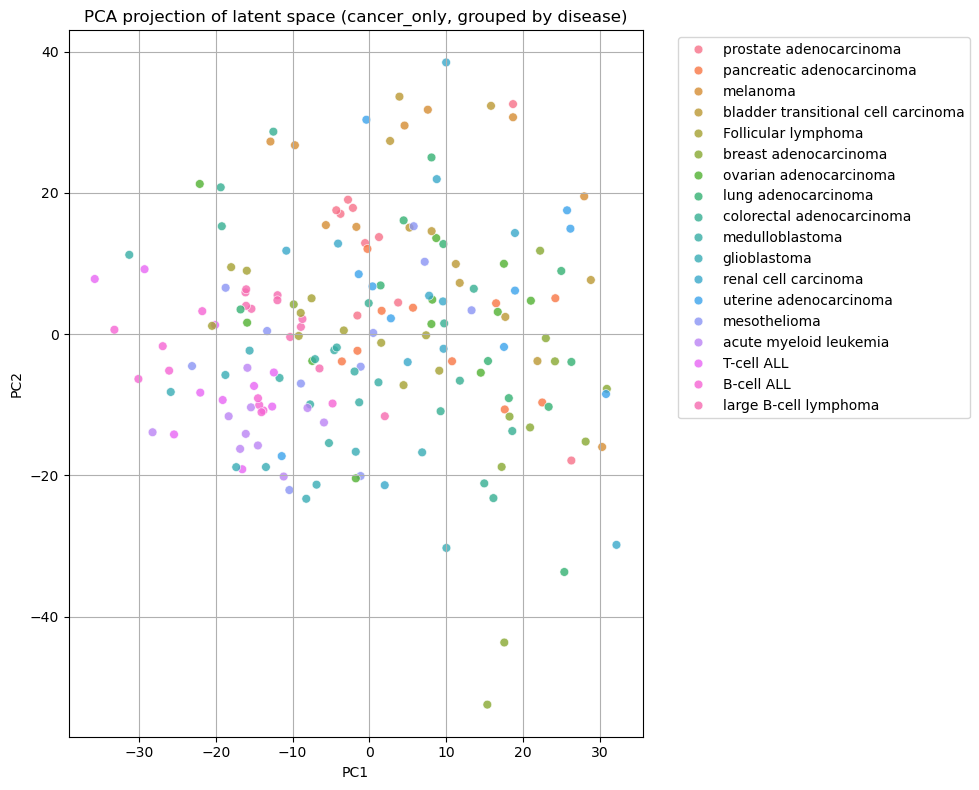

In [7]:
plt.figure(figsize=(10, 8))

if HAS_SNS:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="group_label", s=40, alpha=0.8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    for grp, sub in pca_df.groupby("group_label"):
        plt.scatter(sub["PC1"], sub["PC2"], label=grp, s=40, alpha=0.8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.title(f"PCA projection of latent space ({ANALYSIS_SCOPE}, grouped by {GROUPING})")
plt.tight_layout()
plt.savefig(NB6_PLOT_DIR / "pca_latent_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\drziy\anaconda3\envs\ml\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


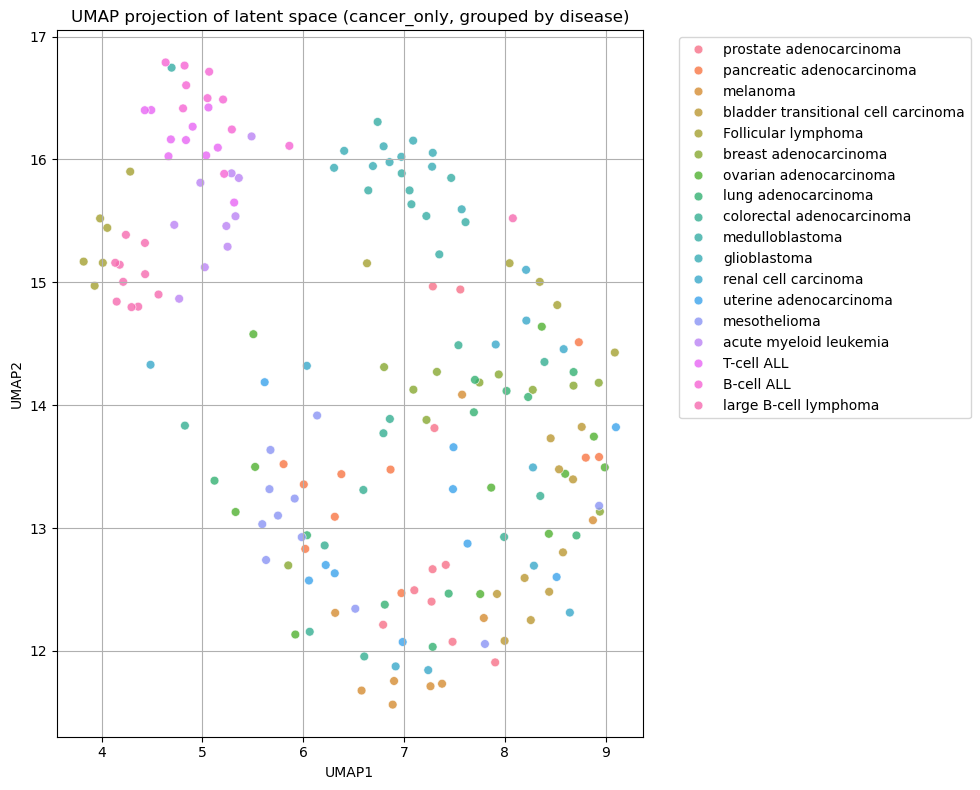

In [8]:
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)

    umap_df = analysis_df[["sample_id", "geo_accession", "group_label", "tissue", "disease", "state"]].copy()
    umap_df["UMAP1"] = X_umap[:, 0]
    umap_df["UMAP2"] = X_umap[:, 1]

    plt.figure(figsize=(10, 8))
    if HAS_SNS:
        sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="group_label", s=40, alpha=0.8)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        for grp, sub in umap_df.groupby("group_label"):
            plt.scatter(sub["UMAP1"], sub["UMAP2"], label=grp, s=40, alpha=0.8)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.title(f"UMAP projection of latent space ({ANALYSIS_SCOPE}, grouped by {GROUPING})")
    plt.tight_layout()
    plt.savefig(NB6_PLOT_DIR / "umap_latent_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("UMAP not installed; skipping UMAP plot.")

## Group centroids

In [9]:
centroids = compute_centroids(analysis_df, "group_label", latent_cols)
display(centroids.head())

centroids.to_csv(NB6_TABLE_DIR / "group_centroids.csv")

,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10
group_label,,,,,,,,,,
B-cell ALL,-3.002250,-12.716127,5.552105,0.693173,-3.659720,13.621152,5.134582,2.240982,-18.799097,-1.602455
Follicular lymphoma,-2.417580,7.791016,0.754800,6.387079,1.335066,7.185501,-1.095063,3.936309,-18.403994,3.167262
T-cell ALL,-2.736069,-6.817913,1.768764,-0.840539,-7.668540,14.163480,6.380502,0.521880,-16.655722,-11.475299
acute myeloid leukemia,-11.165013,-3.328722,-2.055399,-5.871749,-9.761980,2.542465,2.105493,-0.698011,-14.161570,-6.336851
bladder transitional cell carcinoma,9.232477,12.419455,-6.452957,3.810701,10.742674,14.906937,-5.221364,3.480527,-2.780081,10.392889


In [10]:
centroid_dist = pairwise_distance_df(centroids, metric="euclidean")
display(centroid_dist.round(3))

centroid_dist.to_csv(NB6_TABLE_DIR / "centroid_distance_matrix.csv")

group_label,B-cell ALL,Follicular lymphoma,T-cell ALL,acute myeloid leukemia,bladder transitional cell carcinoma,breast adenocarcinoma,colorectal adenocarcinoma,glioblastoma,large B-cell lymphoma,lung adenocarcinoma,medulloblastoma,melanoma,mesothelioma,ovarian adenocarcinoma,pancreatic adenocarcinoma,prostate adenocarcinoma,renal cell carcinoma,uterine adenocarcinoma
group_label,,,,,,,,,,,,,,,,,,
B-cell ALL,0.000,24.643,13.209,21.850,40.666,42.917,33.504,36.595,23.442,38.432,28.983,45.244,37.122,31.037,39.504,37.797,34.349,42.189
Follicular lymphoma,24.643,0.000,26.107,25.359,26.027,37.249,29.478,39.780,11.686,30.134,26.057,36.965,37.542,21.834,29.447,29.708,22.758,36.933
T-cell ALL,13.209,26.107,0.000,17.748,41.907,43.914,32.366,37.453,22.315,38.980,32.521,42.924,32.423,31.423,37.104,38.851,35.604,39.599
acute myeloid leukemia,21.850,25.359,17.748,0.000,42.791,36.779,26.643,36.238,19.568,35.313,36.112,45.434,28.211,28.334,30.491,38.020,32.275,37.030
bladder transitional cell carcinoma,40.666,26.027,41.907,42.791,0.000,33.354,27.418,47.142,31.944,21.852,34.872,27.872,40.863,20.124,26.522,23.419,15.301,29.045
breast adenocarcinoma,42.917,37.249,43.914,36.779,33.354,0.000,22.760,40.983,39.178,17.585,41.598,41.776,33.393,24.292,22.823,33.389,24.230,26.511
colorectal adenocarcinoma,33.504,29.478,32.366,26.643,27.418,22.760,0.000,40.265,27.544,14.168,40.260,31.544,18.686,13.983,12.381,23.475,16.471,18.513
glioblastoma,36.595,39.780,37.453,36.238,47.142,40.983,40.265,0.000,40.363,40.052,25.063,51.704,41.952,33.864,39.799,38.986,36.478,43.999
large B-cell lymphoma,23.442,11.686,22.315,19.568,31.944,39.178,27.544,40.363,0.000,31.764,32.081,34.409,31.710,22.265,28.784,30.001,25.458,34.123


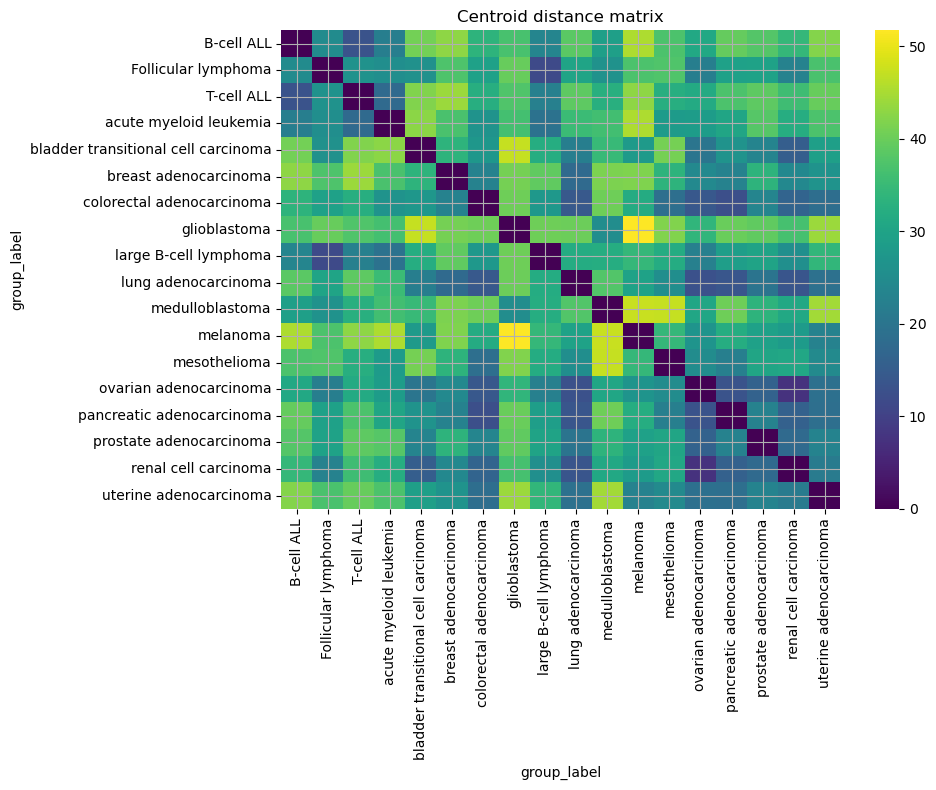

In [11]:
plt.figure(figsize=(10, 8))

if HAS_SNS:
    sns.heatmap(centroid_dist, cmap="viridis", annot=False)
else:
    plt.imshow(centroid_dist.values, aspect="auto")
    plt.colorbar(label="Euclidean distance")
    plt.xticks(range(len(centroid_dist.columns)), centroid_dist.columns, rotation=90)
    plt.yticks(range(len(centroid_dist.index)), centroid_dist.index)

plt.title("Centroid distance matrix")
plt.tight_layout()
plt.savefig(NB6_PLOT_DIR / "centroid_distance_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
centroid_pairs = upper_triangle_pairs(
    centroid_dist,
    value_col="centroid_distance",
    row_name="group_a",
    col_name="group_b",
).sort_values("centroid_distance")

display(centroid_pairs.head(10))
display(centroid_pairs.tail(10))

centroid_pairs.to_csv(NB6_TABLE_DIR / "centroid_distance_pairs_ranked.csv", index=False)

,group_a,group_b,centroid_distance
145,ovarian adenocarcinoma,renal cell carcinoma,7.383474
23,Follicular lymphoma,large B-cell lymphoma,11.685669
94,colorectal adenocarcinoma,pancreatic adenocarcinoma,12.381317
120,lung adenocarcinoma,ovarian adenocarcinoma,12.844087
1,B-cell ALL,T-cell ALL,13.208528
143,ovarian adenocarcinoma,pancreatic adenocarcinoma,13.286411
123,lung adenocarcinoma,renal cell carcinoma,13.731924
121,lung adenocarcinoma,pancreatic adenocarcinoma,13.887761
93,colorectal adenocarcinoma,ovarian adenocarcinoma,13.983218
89,colorectal adenocarcinoma,lung adenocarcinoma,14.167557


,group_a,group_b,centroid_distance
41,T-cell ALL,melanoma,42.924345
35,T-cell ALL,breast adenocarcinoma,43.913886
107,glioblastoma,uterine adenocarcinoma,43.999425
131,medulloblastoma,uterine adenocarcinoma,44.532403
10,B-cell ALL,melanoma,45.244420
55,acute myeloid leukemia,melanoma,45.433775
126,medulloblastoma,mesothelioma,47.073192
64,bladder transitional cell carcinoma,glioblastoma,47.141873
125,medulloblastoma,melanoma,47.456967
101,glioblastoma,melanoma,51.703900


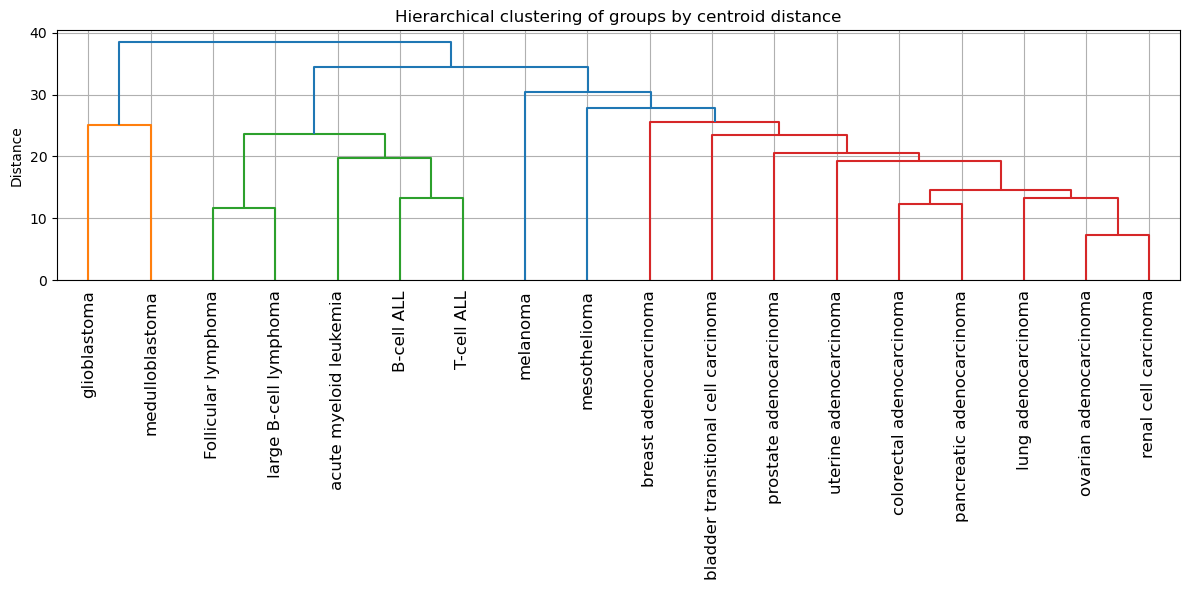

In [13]:
Z = linkage(squareform(centroid_dist.values), method="average")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=centroid_dist.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical clustering of groups by centroid distance")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(NB6_PLOT_DIR / "group_centroid_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

## Dispersion-aware separation

Centroid distance alone can be misleading. Two groups may have close centroids but compact clouds, or distant centroids but broad overlapping clouds. We therefore normalize separation by pooled spread.

In [14]:
dispersion_df = compute_group_dispersion(analysis_df, "group_label", latent_cols)
dispersion_df = dispersion_df.sort_values("mean_radius", ascending=False)

display(dispersion_df)
dispersion_df.to_csv(NB6_TABLE_DIR / "group_dispersion_summary.csv", index=False)

,group_label,n_samples,mean_radius,median_radius,rms_radius,std_radius
5,breast adenocarcinoma,11,30.178578,30.910397,32.050548,10.793100
11,melanoma,9,29.591341,27.533411,31.831486,11.730133
17,uterine adenocarcinoma,10,28.414816,28.507652,29.324774,7.248489
16,renal cell carcinoma,11,27.882033,23.068542,30.289383,11.833808
6,colorectal adenocarcinoma,11,27.708412,26.561059,28.903496,8.225326
9,lung adenocarcinoma,11,25.736663,21.704758,26.775148,7.384629
13,ovarian adenocarcinoma,11,25.331491,21.704411,27.324672,10.244670
14,pancreatic adenocarcinoma,10,23.132092,21.594920,23.957373,6.233941
7,glioblastoma,10,22.012531,22.171256,22.261076,3.317223
15,prostate adenocarcinoma,10,21.765361,18.479863,23.706041,9.393903


In [15]:
normalized_sep = compute_normalized_separation(
    centroids_df=centroids,
    dispersion_df=dispersion_df,
    group_col="group_label",
    radius_col="rms_radius",
)

display(normalized_sep.round(3))
normalized_sep.to_csv(NB6_TABLE_DIR / "normalized_separation_matrix.csv")

,B-cell ALL,Follicular lymphoma,T-cell ALL,acute myeloid leukemia,bladder transitional cell carcinoma,breast adenocarcinoma,colorectal adenocarcinoma,glioblastoma,large B-cell lymphoma,lung adenocarcinoma,medulloblastoma,melanoma,mesothelioma,ovarian adenocarcinoma,pancreatic adenocarcinoma,prostate adenocarcinoma,renal cell carcinoma,uterine adenocarcinoma
B-cell ALL,0.000,0.745,0.448,0.743,1.154,0.907,0.758,0.975,0.804,0.914,0.804,0.960,0.978,0.728,1.007,0.970,0.754,0.946
Follicular lymphoma,0.745,0.000,0.816,0.795,0.690,0.748,0.631,0.993,0.369,0.676,0.676,0.745,0.928,0.484,0.706,0.716,0.473,0.784
T-cell ALL,0.448,0.816,0.000,0.626,1.227,0.949,0.751,1.027,0.794,0.951,0.930,0.932,0.879,0.757,0.972,1.025,0.800,0.910
acute myeloid leukemia,0.743,0.795,0.626,0.000,1.256,0.796,0.619,0.996,0.699,0.863,1.035,0.989,0.767,0.684,0.801,1.005,0.727,0.852
bladder transitional cell carcinoma,1.154,0.690,1.227,1.256,0.000,0.641,0.561,1.117,0.944,0.468,0.856,0.538,0.959,0.426,0.604,0.536,0.305,0.589
breast adenocarcinoma,0.907,0.748,0.949,0.796,0.641,0.000,0.373,0.755,0.853,0.299,0.788,0.654,0.610,0.409,0.408,0.599,0.389,0.432
colorectal adenocarcinoma,0.758,0.631,0.751,0.619,0.561,0.373,0.000,0.787,0.644,0.254,0.811,0.519,0.362,0.249,0.234,0.446,0.278,0.318
glioblastoma,0.975,0.993,1.027,0.996,1.117,0.755,0.787,0.000,1.117,0.817,0.583,0.956,0.934,0.683,0.861,0.848,0.694,0.853
large B-cell lymphoma,0.804,0.369,0.794,0.699,0.944,0.853,0.644,1.117,0.000,0.781,0.926,0.753,0.868,0.540,0.761,0.798,0.576,0.790
lung adenocarcinoma,0.914,0.676,0.951,0.863,0.468,0.299,0.254,0.817,0.781,0.000,0.793,0.508,0.512,0.237,0.274,0.393,0.241,0.340


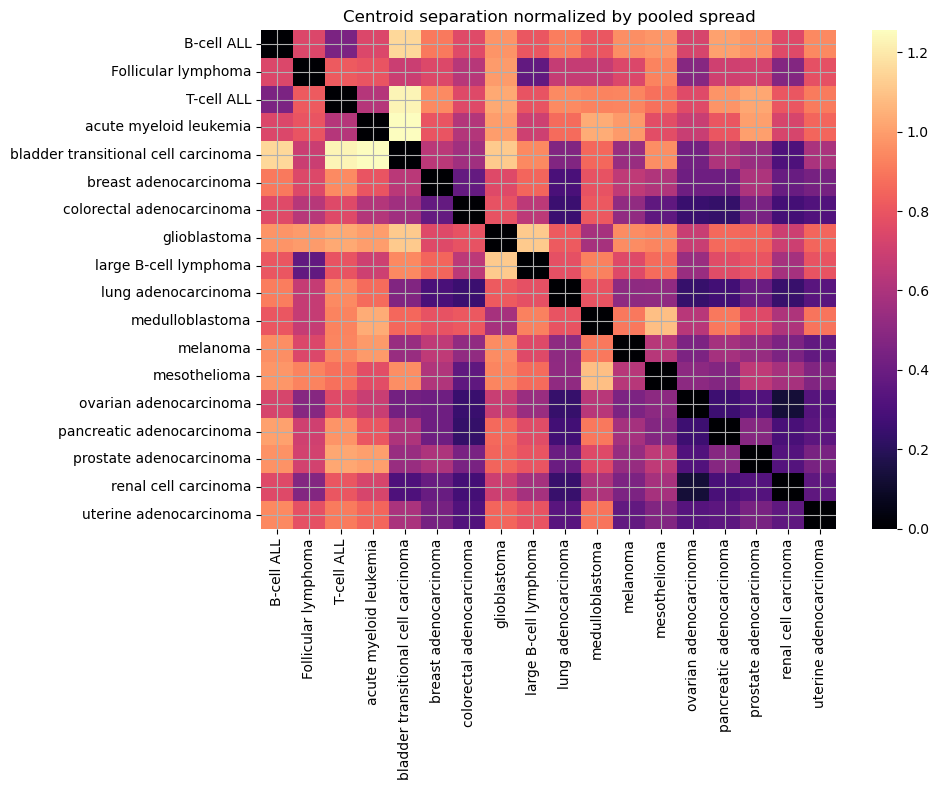

In [16]:
plt.figure(figsize=(10, 8))

if HAS_SNS:
    sns.heatmap(normalized_sep, cmap="magma", annot=False)
else:
    plt.imshow(normalized_sep.values, aspect="auto")
    plt.colorbar(label="Normalized separation")
    plt.xticks(range(len(normalized_sep.columns)), normalized_sep.columns, rotation=90)
    plt.yticks(range(len(normalized_sep.index)), normalized_sep.index)

plt.title("Centroid separation normalized by pooled spread")
plt.tight_layout()
plt.savefig(NB6_PLOT_DIR / "normalized_separation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
normalized_sep_pairs = upper_triangle_pairs(
    normalized_sep,
    value_col="normalized_separation",
    row_name="group_a",
    col_name="group_b",
).sort_values("normalized_separation")

display(normalized_sep_pairs.head(10))
display(normalized_sep_pairs.tail(10))

normalized_sep_pairs.to_csv(NB6_TABLE_DIR / "normalized_separation_pairs_ranked.csv", index=False)

,group_a,group_b,normalized_separation
145,ovarian adenocarcinoma,renal cell carcinoma,0.128154
94,colorectal adenocarcinoma,pancreatic adenocarcinoma,0.234225
120,lung adenocarcinoma,ovarian adenocarcinoma,0.237415
123,lung adenocarcinoma,renal cell carcinoma,0.240639
93,colorectal adenocarcinoma,ovarian adenocarcinoma,0.248687
89,colorectal adenocarcinoma,lung adenocarcinoma,0.254452
143,ovarian adenocarcinoma,pancreatic adenocarcinoma,0.259085
121,lung adenocarcinoma,pancreatic adenocarcinoma,0.273745
96,colorectal adenocarcinoma,renal cell carcinoma,0.278255
148,pancreatic adenocarcinoma,renal cell carcinoma,0.293830


,group_a,group_b,normalized_separation
13,B-cell ALL,pancreatic adenocarcinoma,1.006791
45,T-cell ALL,prostate adenocarcinoma,1.024666
37,T-cell ALL,glioblastoma,1.026946
54,acute myeloid leukemia,medulloblastoma,1.035056
126,medulloblastoma,mesothelioma,1.084029
64,bladder transitional cell carcinoma,glioblastoma,1.116724
98,glioblastoma,large B-cell lymphoma,1.116874
3,B-cell ALL,bladder transitional cell carcinoma,1.154187
34,T-cell ALL,bladder transitional cell carcinoma,1.226690
48,acute myeloid leukemia,bladder transitional cell carcinoma,1.255624


## Local neighborhood mixing

For each sample, compute the fraction of its nearest neighbors that belong to the same group. High values indicate local purity; lower values indicate overlap or boundary mixing.

In [18]:
knn_sample_df, knn_indices, k_eff = compute_knn_mixing(
    analysis_df,
    group_col="group_label",
    latent_cols=latent_cols,
    k=K_NEIGHBORS,
    sample_id_col="sample_id",
)

print("Requested k:", K_NEIGHBORS)
print("Effective k:", k_eff)

display(knn_sample_df.head())
knn_sample_df.to_csv(NB6_TABLE_DIR / f"knn_sample_mixing_k{k_eff}.csv", index=False)

Requested k: 10
Effective k: 10


,sample_id,group_label,same_group_neighbor_fraction
0,GSM1686773_CL2000062805AA.CEL,prostate adenocarcinoma,0.1
1,GSM1686774_CL2000062807AA.CEL,prostate adenocarcinoma,0.3
2,GSM1686792_CL2000071833AA.CEL,pancreatic adenocarcinoma,0.0
3,GSM1686793_CL2000071834AA.CEL,melanoma,0.0
4,GSM1686794_CL2000071838AA.CEL,bladder transitional cell carcinoma,0.2


In [19]:
knn_group_summary = (
    knn_sample_df.groupby("group_label")["same_group_neighbor_fraction"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
    .rename(
        columns={
            "mean": "mean_same_group_neighbor_fraction",
            "median": "median_same_group_neighbor_fraction",
            "std": "std_same_group_neighbor_fraction",
            "count": "n_samples",
        }
    )
    .sort_values("mean_same_group_neighbor_fraction")
)

display(knn_group_summary)
knn_group_summary.to_csv(NB6_TABLE_DIR / f"knn_group_summary_k{k_eff}.csv", index=False)

,group_label,mean_same_group_neighbor_fraction,median_same_group_neighbor_fraction,std_same_group_neighbor_fraction,n_samples
13,ovarian adenocarcinoma,0.109091,0.10,0.053936,11
16,renal cell carcinoma,0.136364,0.10,0.120605,11
9,lung adenocarcinoma,0.136364,0.20,0.102691,11
6,colorectal adenocarcinoma,0.154545,0.10,0.121356,11
17,uterine adenocarcinoma,0.170000,0.20,0.141814,10
5,breast adenocarcinoma,0.172727,0.20,0.127208,11
14,pancreatic adenocarcinoma,0.230000,0.25,0.194651,10
11,melanoma,0.244444,0.20,0.206828,9
1,Follicular lymphoma,0.254545,0.30,0.129334,11
15,prostate adenocarcinoma,0.260000,0.20,0.245855,10


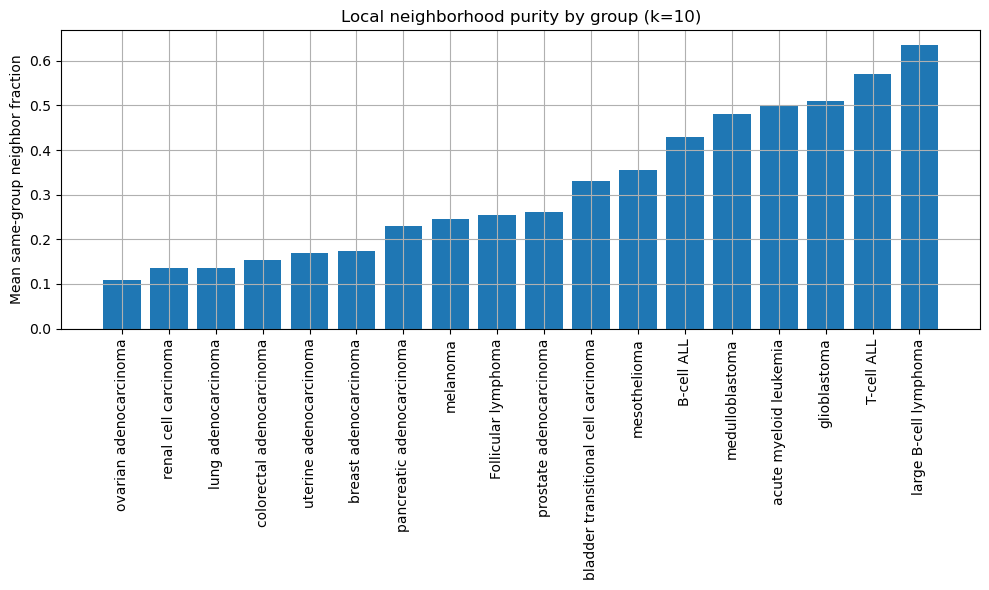

In [20]:
plt.figure(figsize=(10, 6))
plot_df = knn_group_summary.sort_values("mean_same_group_neighbor_fraction")

plt.bar(plot_df["group_label"], plot_df["mean_same_group_neighbor_fraction"])
plt.xticks(rotation=90)
plt.ylabel("Mean same-group neighbor fraction")
plt.title(f"Local neighborhood purity by group (k={k_eff})")
plt.tight_layout()
plt.savefig(NB6_PLOT_DIR / f"same_group_neighbor_fraction_barplot_k{k_eff}.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
mixing_matrix = compute_pairwise_mixing_matrix(
    analysis_df,
    group_col="group_label",
    indices=knn_indices,
)

display(mixing_matrix.round(3))
mixing_matrix.to_csv(NB6_TABLE_DIR / f"pairwise_mixing_matrix_k{k_eff}.csv")

,B-cell ALL,Follicular lymphoma,T-cell ALL,acute myeloid leukemia,bladder transitional cell carcinoma,breast adenocarcinoma,colorectal adenocarcinoma,glioblastoma,large B-cell lymphoma,lung adenocarcinoma,medulloblastoma,melanoma,mesothelioma,ovarian adenocarcinoma,pancreatic adenocarcinoma,prostate adenocarcinoma,renal cell carcinoma,uterine adenocarcinoma
B-cell ALL,0.430,0.020,0.410,0.140,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Follicular lymphoma,0.018,0.255,0.045,0.018,0.027,0.009,0.000,0.000,0.409,0.018,0.018,0.000,0.009,0.073,0.000,0.000,0.091,0.009
T-cell ALL,0.240,0.010,0.570,0.170,0.000,0.000,0.000,0.000,0.010,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
acute myeloid leukemia,0.110,0.020,0.240,0.500,0.000,0.000,0.000,0.000,0.120,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.010
bladder transitional cell carcinoma,0.000,0.000,0.000,0.000,0.330,0.040,0.000,0.000,0.000,0.060,0.000,0.020,0.070,0.190,0.070,0.060,0.160,0.000
breast adenocarcinoma,0.000,0.027,0.000,0.009,0.100,0.173,0.155,0.009,0.018,0.164,0.000,0.009,0.064,0.136,0.045,0.000,0.027,0.064
colorectal adenocarcinoma,0.000,0.018,0.018,0.000,0.055,0.100,0.155,0.009,0.018,0.127,0.000,0.027,0.091,0.073,0.118,0.045,0.082,0.064
glioblastoma,0.000,0.000,0.050,0.040,0.000,0.010,0.020,0.510,0.020,0.020,0.300,0.000,0.000,0.010,0.000,0.000,0.020,0.000
large B-cell lymphoma,0.018,0.218,0.018,0.064,0.000,0.000,0.000,0.000,0.636,0.009,0.018,0.000,0.000,0.009,0.000,0.000,0.009,0.000
lung adenocarcinoma,0.000,0.018,0.000,0.009,0.109,0.173,0.100,0.000,0.018,0.136,0.000,0.027,0.109,0.109,0.091,0.000,0.055,0.045


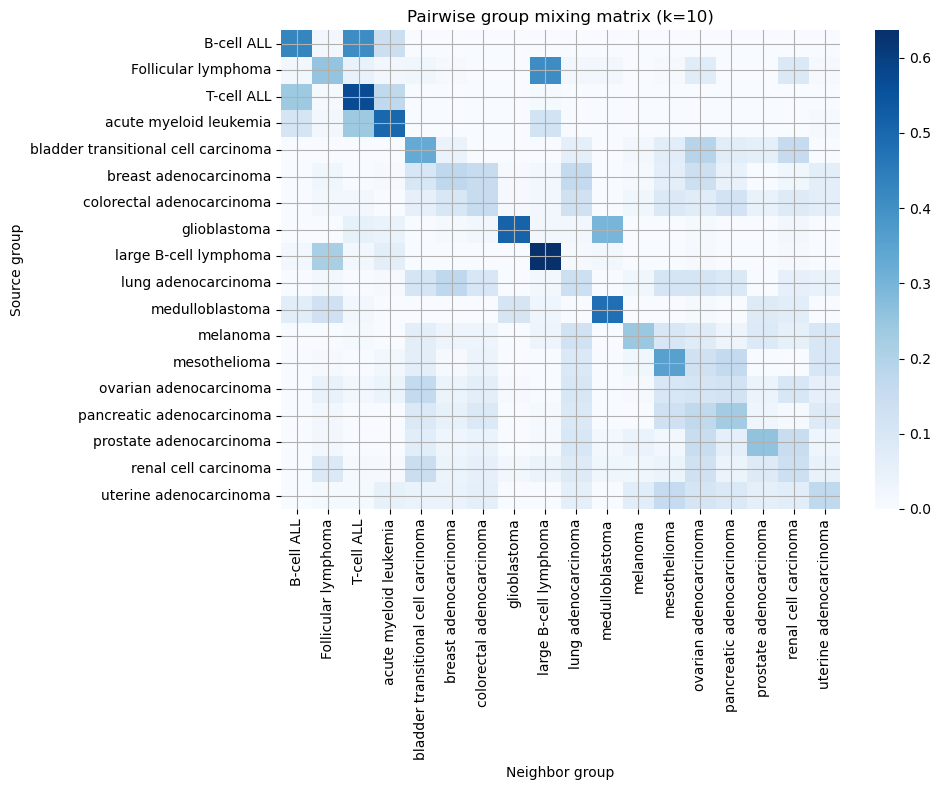

In [22]:
plt.figure(figsize=(10, 8))

if HAS_SNS:
    sns.heatmap(mixing_matrix, cmap="Blues", annot=False)
else:
    plt.imshow(mixing_matrix.values, aspect="auto")
    plt.colorbar(label="Average neighbor fraction")
    plt.xticks(range(len(mixing_matrix.columns)), mixing_matrix.columns, rotation=90)
    plt.yticks(range(len(mixing_matrix.index)), mixing_matrix.index)

plt.title(f"Pairwise group mixing matrix (k={k_eff})")
plt.xlabel("Neighbor group")
plt.ylabel("Source group")
plt.tight_layout()
plt.savefig(NB6_PLOT_DIR / f"pairwise_mixing_heatmap_k{k_eff}.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
mixing_long = (
    mixing_matrix.reset_index()
    .rename(columns={"index": "source_group"})
    .melt(id_vars="source_group", var_name="neighbor_group", value_name="mixing_fraction")
)

mixing_long = mixing_long[mixing_long["source_group"] != mixing_long["neighbor_group"]]
mixing_long = mixing_long.sort_values("mixing_fraction", ascending=False)

display(mixing_long.head(15))
mixing_long.to_csv(NB6_TABLE_DIR / f"off_diagonal_mixing_ranked_k{k_eff}.csv", index=False)

,source_group,neighbor_group,mixing_fraction
36,B-cell ALL,T-cell ALL,0.410000
145,Follicular lymphoma,large B-cell lymphoma,0.409091
187,glioblastoma,medulloblastoma,0.300000
2,T-cell ALL,B-cell ALL,0.240000
39,acute myeloid leukemia,T-cell ALL,0.240000
26,large B-cell lymphoma,Follicular lymphoma,0.218182
238,bladder transitional cell carcinoma,ovarian adenocarcinoma,0.190000
99,lung adenocarcinoma,breast adenocarcinoma,0.172727
248,pancreatic adenocarcinoma,ovarian adenocarcinoma,0.170000
56,T-cell ALL,acute myeloid leukemia,0.170000


## Silhouette analysis

Silhouette analysis measures how well each sample fits within its own group relative to neighboring groups. Higher values indicate cleaner separation; lower or negative values suggest overlap or ambiguity.

In [24]:
sil_sample_df, sil_group_df, global_sil = compute_group_silhouette(
    analysis_df,
    group_col="group_label",
    latent_cols=latent_cols,
    sample_id_col="sample_id",
)

print("Global silhouette score:", round(global_sil, 4))
display(sil_group_df.sort_values("mean_silhouette"))

sil_sample_df.to_csv(NB6_TABLE_DIR / "sample_silhouette_scores.csv", index=False)
sil_group_df.to_csv(NB6_TABLE_DIR / "group_silhouette_summary.csv", index=False)

Global silhouette score: -0.011


,group_label,mean_silhouette,median_silhouette,std_silhouette,n_samples
16,renal cell carcinoma,-0.233331,-0.234103,0.052712,11
13,ovarian adenocarcinoma,-0.210350,-0.235046,0.074971,11
17,uterine adenocarcinoma,-0.163576,-0.199697,0.171358,10
6,colorectal adenocarcinoma,-0.144713,-0.143520,0.062995,11
9,lung adenocarcinoma,-0.136725,-0.136322,0.121372,11
5,breast adenocarcinoma,-0.134037,-0.089455,0.164519,11
14,pancreatic adenocarcinoma,-0.102856,-0.060865,0.133404,10
11,melanoma,-0.095961,-0.142512,0.183720,9
1,Follicular lymphoma,-0.053471,-0.035213,0.107632,11
15,prostate adenocarcinoma,0.060936,-0.000084,0.241068,10


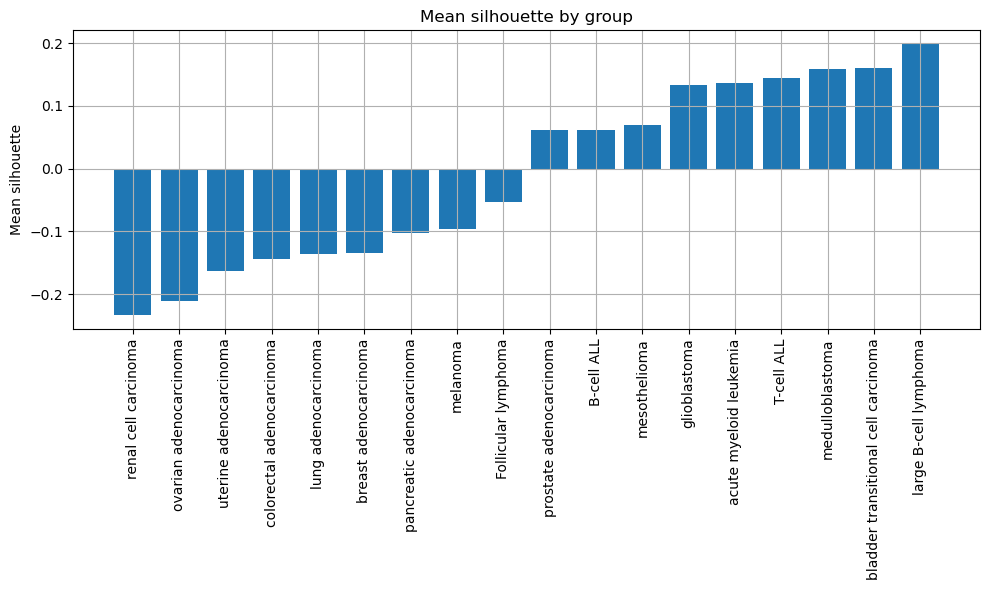

In [25]:
plt.figure(figsize=(10, 6))
plot_df = sil_group_df.sort_values("mean_silhouette")

plt.bar(plot_df["group_label"], plot_df["mean_silhouette"])
plt.xticks(rotation=90)
plt.ylabel("Mean silhouette")
plt.title("Mean silhouette by group")
plt.tight_layout()
plt.savefig(NB6_PLOT_DIR / "mean_silhouette_by_group.png", dpi=300, bbox_inches="tight")
plt.show()

## Unified group-level geometry summary

In [26]:
nearest_other_rows = []

for grp in centroid_dist.index:
    s = centroid_dist.loc[grp].drop(index=grp)
    nearest_other_rows.append(
        {
            "group_label": grp,
            "nearest_other_group": s.idxmin(),
            "distance_to_nearest_other_group": s.min(),
            "mean_centroid_distance_to_others": s.mean(),
        }
    )

nearest_other_df = pd.DataFrame(nearest_other_rows)

group_geometry_summary = (
    dispersion_df.merge(knn_group_summary, on=["group_label", "n_samples"], how="outer")
    .merge(
        sil_group_df[["group_label", "mean_silhouette", "median_silhouette", "std_silhouette"]],
        on="group_label",
        how="outer",
    )
    .merge(nearest_other_df, on="group_label", how="outer")
)

# Add comparison metadata INSIDE Notebook 6 (standalone, no Notebook 5 dependency)
comparison_meta_df = build_comparison_metadata(analysis_df, group_col="group_label")

group_geometry_summary = (
    group_geometry_summary
    .merge(comparison_meta_df, on="group_label", how="left")
    .sort_values(["comparison", "group_label"])
    .reset_index(drop=True)
)

# Basic standalone derived fields
group_geometry_summary["superclass"] = (
    group_geometry_summary["group_label"].map(SUPERCLASS_MAP).fillna("other")
)
group_geometry_summary["separation_class"] = group_geometry_summary.apply(
    lambda r: classify_separation(
        r.get("mean_silhouette", np.nan),
        r.get("mean_same_group_neighbor_fraction", np.nan),
    ),
    axis=1,
)

# Useful QC flags
group_geometry_summary["has_short_code"] = (
    group_geometry_summary["comparison_source"] == "short_code"
)

display(group_geometry_summary)

group_geometry_summary.to_csv(NB6_TABLE_DIR / "group_geometry_summary.csv", index=False)
group_geometry_summary.to_csv(NB6_TABLE_DIR / "latent_geometry_metrics_full.csv", index=False)

print("Rows in group_geometry_summary:", group_geometry_summary.shape[0])
print("Unique comparisons           :", group_geometry_summary["comparison"].nunique())

unmapped = group_geometry_summary.loc[~group_geometry_summary["has_short_code"], [
    "group_label", "comparison", "comparison_long"
]]
if not unmapped.empty:
    print("\nGroups using fallback comparison labels (not dissertation short codes):")
    display(unmapped)
else:
    print("\nAll retained groups mapped to dissertation-style short codes.")

,group_label,n_samples,mean_radius,median_radius,rms_radius,std_radius,mean_same_group_neighbor_fraction,median_same_group_neighbor_fraction,std_same_group_neighbor_fraction,mean_silhouette,median_silhouette,std_silhouette,nearest_other_group,distance_to_nearest_other_group,mean_centroid_distance_to_others,tumor_disease,normal_tissue,comparison,comparison_long,comparison_source,superclass,separation_class,has_short_code
0,bladder transitional cell carcinoma,10,18.738992,17.845773,19.953345,6.854646,0.330000,0.30,0.115950,0.160894,0.175657,0.052415,renal cell carcinoma,15.301477,31.242196,bladder transitional cell carcinoma,Bladder,BLAD/TCC,Bladder/bladder transitional cell carcinoma,short_code,urologic,moderate separation,True
1,breast adenocarcinoma,11,30.178578,30.910397,32.050548,10.793100,0.172727,0.20,0.127208,-0.134037,-0.089455,0.164519,lung adenocarcinoma,17.585413,33.101891,breast adenocarcinoma,Breast,BR/BRAD,Breast/breast adenocarcinoma,short_code,epithelial,low separation,True
2,acute myeloid leukemia,10,13.515832,13.200754,14.125837,4.106282,0.500000,0.55,0.182574,0.135761,0.101831,0.154122,T-cell ALL,17.747608,31.658598,acute myeloid leukemia,Bone Marrow,Bone Marrow/acute myeloid leukemia,Bone Marrow/acute myeloid leukemia,fallback_long,hematologic,high separation,False
3,glioblastoma,10,22.012531,22.171256,22.261076,3.317223,0.510000,0.50,0.172884,0.132910,0.133755,0.085631,medulloblastoma,25.063225,39.453843,glioblastoma,Brain,Brain/GBM,Brain/glioblastoma,short_code,CNS,high separation,True
4,medulloblastoma,10,19.155003,15.607455,20.763350,8.012649,0.480000,0.50,0.103280,0.158999,0.147329,0.103356,glioblastoma,25.063225,35.855021,medulloblastoma,Brain,Brain/MB,Brain/medulloblastoma,short_code,CNS,high separation,True
5,colorectal adenocarcinoma,11,27.708412,26.561059,28.903496,8.225326,0.154545,0.10,0.121356,-0.144713,-0.143520,0.062995,pancreatic adenocarcinoma,12.381317,25.262262,colorectal adenocarcinoma,Colon,COL/COADREAD,Colon/colorectal adenocarcinoma,short_code,epithelial,low separation,True
6,Follicular lymphoma,11,17.191157,17.933405,17.780206,4.538706,0.254545,0.30,0.129334,-0.053471,-0.035213,0.107632,large B-cell lymphoma,11.685669,28.923930,Follicular lymphoma,Lymphoid Tissue,GC/FL,Lymphoid Tissue/Follicular lymphoma,short_code,hematologic,low separation,True
7,large B-cell lymphoma,11,12.686540,12.170040,13.878603,5.627371,0.636364,0.70,0.224823,0.198690,0.221069,0.131727,Follicular lymphoma,11.685669,28.625532,large B-cell lymphoma,Lymphoid Tissue,GC/LBCL,Lymphoid Tissue/large B-cell lymphoma,short_code,hematologic,high separation,True
8,renal cell carcinoma,11,27.882033,23.068542,30.289383,11.833808,0.136364,0.10,0.120605,-0.233331,-0.234103,0.052712,ovarian adenocarcinoma,7.383474,24.050590,renal cell carcinoma,Kidney,KID/RCC,Kidney/renal cell carcinoma,short_code,urologic,low separation,True
9,lung adenocarcinoma,11,25.736663,21.704758,26.775148,7.384629,0.136364,0.20,0.102691,-0.136725,-0.136322,0.121372,ovarian adenocarcinoma,12.844087,25.908709,lung adenocarcinoma,Lung,LU/LUAD,Lung/lung adenocarcinoma,short_code,epithelial,low separation,True


Rows in group_geometry_summary: 18
Unique comparisons           : 18

Groups using fallback comparison labels (not dissertation short codes):


,group_label,comparison,comparison_long
2,acute myeloid leukemia,Bone Marrow/acute myeloid leukemia,Bone Marrow/acute myeloid leukemia
10,mesothelioma,Mesothelium/mesothelioma,Mesothelium/mesothelioma
16,melanoma,Skin/melanoma,Skin/melanoma


In [27]:
# Notebook 6 is now intentionally standalone.
# No Notebook 5 handoff is used here.

print("Notebook 6 standalone mode: no Notebook 5 metrics are loaded.")
print("Primary export for downstream R merge:", NB6_TABLE_DIR / "latent_geometry_metrics_full.csv")

comparison_qc = (
    group_geometry_summary[
        [
            "group_label",
            "normal_tissue",
            "tumor_disease",
            "comparison",
            "comparison_long",
            "comparison_source",
        ]
    ]
    .drop_duplicates()
    .sort_values(["comparison_source", "comparison"])
    .reset_index(drop=True)
)

display(comparison_qc)
comparison_qc.to_csv(NB6_TABLE_DIR / "comparison_mapping_qc.csv", index=False)

Notebook 6 standalone mode: no Notebook 5 metrics are loaded.
Primary export for downstream R merge: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\tables\latent\notebook_06\latent_geometry_metrics_full.csv


,group_label,normal_tissue,tumor_disease,comparison,comparison_long,comparison_source
0,acute myeloid leukemia,Bone Marrow,acute myeloid leukemia,Bone Marrow/acute myeloid leukemia,Bone Marrow/acute myeloid leukemia,fallback_long
1,mesothelioma,Mesothelium,mesothelioma,Mesothelium/mesothelioma,Mesothelium/mesothelioma,fallback_long
2,melanoma,Skin,melanoma,Skin/melanoma,Skin/melanoma,fallback_long
3,bladder transitional cell carcinoma,Bladder,bladder transitional cell carcinoma,BLAD/TCC,Bladder/bladder transitional cell carcinoma,short_code
4,breast adenocarcinoma,Breast,breast adenocarcinoma,BR/BRAD,Breast/breast adenocarcinoma,short_code
5,glioblastoma,Brain,glioblastoma,Brain/GBM,Brain/glioblastoma,short_code
6,medulloblastoma,Brain,medulloblastoma,Brain/MB,Brain/medulloblastoma,short_code
7,colorectal adenocarcinoma,Colon,colorectal adenocarcinoma,COL/COADREAD,Colon/colorectal adenocarcinoma,short_code
8,Follicular lymphoma,Lymphoid Tissue,Follicular lymphoma,GC/FL,Lymphoid Tissue/Follicular lymphoma,short_code
9,large B-cell lymphoma,Lymphoid Tissue,large B-cell lymphoma,GC/LBCL,Lymphoid Tissue/large B-cell lymphoma,short_code


## Optional legacy CSV overlays and interactive views


# Create the working merged_summary from Notebook 6 output alone.
merged_summary = group_geometry_summary.copy()

# Sanity checks: one row per group_label and one comparison per group_label
dup_group = merged_summary["group_label"].duplicated().sum()
print("Duplicated group_label rows:", dup_group)

group_to_comp = (
    merged_summary.groupby("group_label")["comparison"]
    .nunique()
    .reset_index(name="n_comparisons")
)
bad_group_map = group_to_comp.loc[group_to_comp["n_comparisons"] > 1]

if not bad_group_map.empty:
    print("Warning: some group_label values map to multiple comparison codes.")
    display(bad_group_map)
else:
    print("Each retained group_label maps to exactly one comparison.")

# Notebook 6 internal geometry correlation checks
geometry_cols = [
    c for c in [
        "mean_radius",
        "median_radius",
        "rms_radius",
        "std_radius",
        "mean_same_group_neighbor_fraction",
        "median_same_group_neighbor_fraction",
        "mean_silhouette",
        "median_silhouette",
        "distance_to_nearest_other_group",
        "mean_centroid_distance_to_others",
    ]
    if c in merged_summary.columns
]

corr_rows = []
for i, col_a in enumerate(geometry_cols):
    for col_b in geometry_cols[i + 1:]:
        sub = merged_summary[[col_a, col_b]].dropna()
        if len(sub) >= 3:
            rho, pval = spearmanr(sub[col_a], sub[col_b])
            corr_rows.append(
                {
                    "metric_a": col_a,
                    "metric_b": col_b,
                    "spearman_rho": rho,
                    "p_value": pval,
                    "n": len(sub),
                }
            )

corr_df = pd.DataFrame(corr_rows)
if not corr_df.empty:
    corr_df = corr_df.sort_values("spearman_rho")

display(corr_df)
corr_df.to_csv(NB6_TABLE_DIR / "notebook6_internal_geometry_correlations.csv", index=False)

In [28]:
merged_summary = group_geometry_summary.copy()

entropy_overlay_df = load_overlay_csv(entropy_overlay_path)
complexity_overlay_df = load_overlay_csv(complexity_overlay_path)
legacy_overlay_df = build_overlay_summary(entropy_overlay_df, complexity_overlay_df)

if legacy_overlay_df is not None and "comparison" in merged_summary.columns:
    merged_summary = merged_summary.merge(legacy_overlay_df, on="comparison", how="left")
    print("Legacy overlay merged into merged_summary.")
else:
    print("Legacy overlays not merged (missing files or missing comparison column).")

merged_summary["superclass"] = merged_summary["group_label"].map(SUPERCLASS_MAP).fillna("other")
merged_summary["separation_class"] = merged_summary.apply(
    lambda r: classify_separation(
        r.get("mean_silhouette", np.nan),
        r.get("mean_same_group_neighbor_fraction", np.nan),
    ),
    axis=1,
)

preferred_cols = [
    "comparison",
    "comparison_long",
    "comparison_source",
    "group_label",
    "normal_tissue",
    "tumor_disease",
    "superclass",
    "separation_class",
    "n_samples",
    "mean_silhouette",
    "mean_same_group_neighbor_fraction",
    "mean_radius",
    "median_radius",
    "rms_radius",
    "std_radius",
    "distance_to_nearest_other_group",
    "mean_centroid_distance_to_others",
    "nearest_other_group",
    "shannon_delta",
    "shannon_direction",
    "spectral_delta",
    "spectral_direction",
    "δ svd κ",
    "complexity_direction",
]

display(
    merged_summary[
        [c for c in preferred_cols if c in merged_summary.columns]
    ].sort_values(["superclass", "mean_silhouette"], ascending=[True, True])
)

merged_summary.to_csv(NB6_TABLE_DIR / "group_geometry_with_overlays.csv", index=False)

Loaded overlay: entropy_cleaned.csv -> (3399, 18)
Loaded overlay: complexity_cleaned.csv -> (3399, 26)
Legacy overlay merged into merged_summary.


,comparison,comparison_long,comparison_source,group_label,normal_tissue,tumor_disease,superclass,separation_class,n_samples,mean_silhouette,mean_same_group_neighbor_fraction,mean_radius,median_radius,rms_radius,std_radius,distance_to_nearest_other_group,mean_centroid_distance_to_others,nearest_other_group,shannon_delta,shannon_direction,spectral_delta,spectral_direction,δ svd κ,complexity_direction
3,Brain/GBM,Brain/glioblastoma,short_code,glioblastoma,Brain,glioblastoma,CNS,high separation,10,0.132910,0.510000,22.012531,22.171256,22.261076,3.317223,25.063225,39.453843,medulloblastoma,0.00,neutral,-0.01,neutral,-48.03,lost
4,Brain/MB,Brain/medulloblastoma,short_code,medulloblastoma,Brain,medulloblastoma,CNS,high separation,10,0.158999,0.480000,19.155003,15.607455,20.763350,8.012649,25.063225,35.855021,glioblastoma,0.00,neutral,0.06,neutral,-30.41,lost
11,OV/OVAD,Ovary/ovarian adenocarcinoma,short_code,ovarian adenocarcinoma,Ovary,ovarian adenocarcinoma,epithelial,low separation,11,-0.210350,0.109091,25.331491,21.704411,27.324672,10.244670,7.383474,22.234726,renal cell carcinoma,0.19,mildly chaotic,-0.46,mildly anti-chaotic,7.19,gained
17,UT/EAC,Uterus/uterine adenocarcinoma,short_code,uterine adenocarcinoma,Uterus,uterine adenocarcinoma,epithelial,low separation,10,-0.163576,0.170000,28.414816,28.507652,29.324774,7.248489,18.513492,29.467228,colorectal adenocarcinoma,0.00,neutral,-0.57,strongly anti-chaotic,-8.28,lost
5,COL/COADREAD,Colon/colorectal adenocarcinoma,short_code,colorectal adenocarcinoma,Colon,colorectal adenocarcinoma,epithelial,low separation,11,-0.144713,0.154545,27.708412,26.561059,28.903496,8.225326,12.381317,25.262262,pancreatic adenocarcinoma,0.01,neutral,0.29,mildly chaotic,-75.90,lost
9,LU/LUAD,Lung/lung adenocarcinoma,short_code,lung adenocarcinoma,Lung,lung adenocarcinoma,epithelial,low separation,11,-0.136725,0.136364,25.736663,21.704758,26.775148,7.384629,12.844087,25.908709,ovarian adenocarcinoma,0.01,neutral,0.01,neutral,13.41,gained
1,BR/BRAD,Breast/breast adenocarcinoma,short_code,breast adenocarcinoma,Breast,breast adenocarcinoma,epithelial,low separation,11,-0.134037,0.172727,30.178578,30.910397,32.050548,10.793100,17.585413,33.101891,lung adenocarcinoma,0.01,neutral,0.05,neutral,-35.67,lost
12,PA/PAAD,Pancreas/pancreatic adenocarcinoma,short_code,pancreatic adenocarcinoma,Pancreas,pancreatic adenocarcinoma,epithelial,low separation,10,-0.102856,0.230000,23.132092,21.594920,23.957373,6.233941,12.381317,26.240368,colorectal adenocarcinoma,0.00,neutral,0.44,mildly chaotic,-32.86,lost
15,PR/PRAD,Prostate/prostate adenocarcinoma,short_code,prostate adenocarcinoma,Prostate,prostate adenocarcinoma,epithelial,moderate separation,10,0.060936,0.260000,21.765361,18.479863,23.706041,9.393903,16.020589,28.616494,ovarian adenocarcinoma,NaN,NaN,NaN,NaN,NaN,NaN
6,GC/FL,Lymphoid Tissue/Follicular lymphoma,short_code,Follicular lymphoma,Lymphoid Tissue,Follicular lymphoma,hematologic,low separation,11,-0.053471,0.254545,17.191157,17.933405,17.780206,4.538706,11.685669,28.923930,large B-cell lymphoma,0.17,mildly chaotic,-0.16,mildly anti-chaotic,-8.95,lost


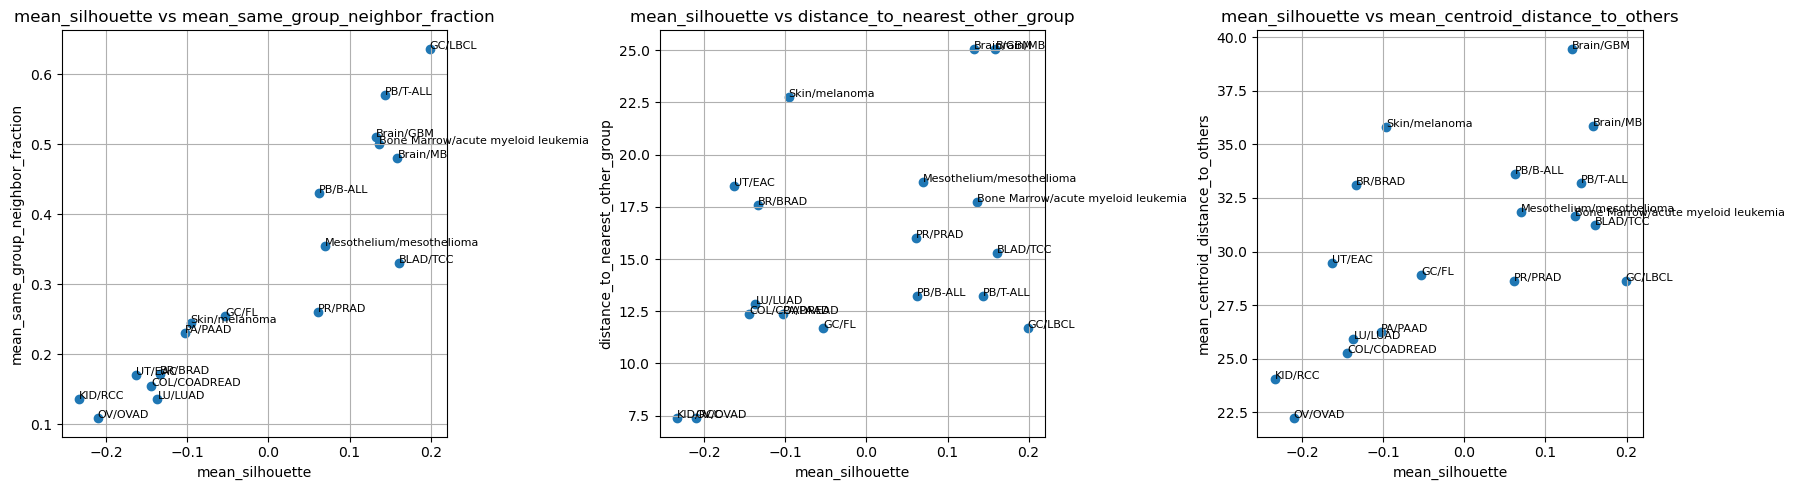

In [29]:
plot_targets = [
    c
    for c in [
        "mean_same_group_neighbor_fraction",
        "distance_to_nearest_other_group",
        "mean_centroid_distance_to_others",
    ]
    if c in merged_summary.columns
]

x_metric = "mean_silhouette"

if x_metric in merged_summary.columns and len(plot_targets) > 0:
    fig, axes = plt.subplots(1, len(plot_targets), figsize=(6 * len(plot_targets), 5))

    if len(plot_targets) == 1:
        axes = [axes]

    for ax, target in zip(axes, plot_targets):
        sub = merged_summary[["group_label", "comparison", x_metric, target]].dropna()
        ax.scatter(sub[x_metric], sub[target])

        for _, row in sub.iterrows():
            label = row["comparison"] if pd.notna(row["comparison"]) else row["group_label"]
            ax.text(row[x_metric], row[target], str(label), fontsize=8)

        ax.set_xlabel(x_metric)
        ax.set_ylabel(target)
        ax.set_title(f"{x_metric} vs {target}")

    plt.tight_layout()
    plt.savefig(
        NB6_PLOT_DIR / f"{x_metric}_vs_geometry_scatterplots.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No eligible geometry targets were found for Notebook 6 scatterplots.")

In [30]:
if HAS_PLOTLY and SHOW_INTERACTIVE_PLOTLY:
    hover_cols = [
        c for c in [
            "group_label",
            "superclass",
            "separation_class",
            "n_samples",
            "mean_silhouette",
            "mean_same_group_neighbor_fraction",
            "mean_radius",
            "nearest_other_group",
            "distance_to_nearest_other_group",
            "comparison",
            "shannon_delta",
            "spectral_delta",
            "δ svd κ",
            "pr_delta",
            "eig_entropy_delta",
            "anisotropy_delta",
        ] if c in merged_summary.columns
    ]

    fig = px.scatter(
        merged_summary,
        x="mean_same_group_neighbor_fraction",
        y="mean_silhouette",
        color="superclass",
        size="n_samples",
        hover_name="group_label",
        hover_data=hover_cols,
        title="Notebook 6: boundary integrity by cancer group",
        color_discrete_map=SUPERCLASS_COLORS,
    )
    fig.update_layout(
        xaxis_title="Mean same-group neighbor fraction",
        yaxis_title="Mean silhouette",
        legend_title="Superclass",
    )
    fig.show()
else:
    print("Plotly not installed or SHOW_INTERACTIVE_PLOTLY=False; skipping interactive overlay scatter.")


## Color-coded graph view


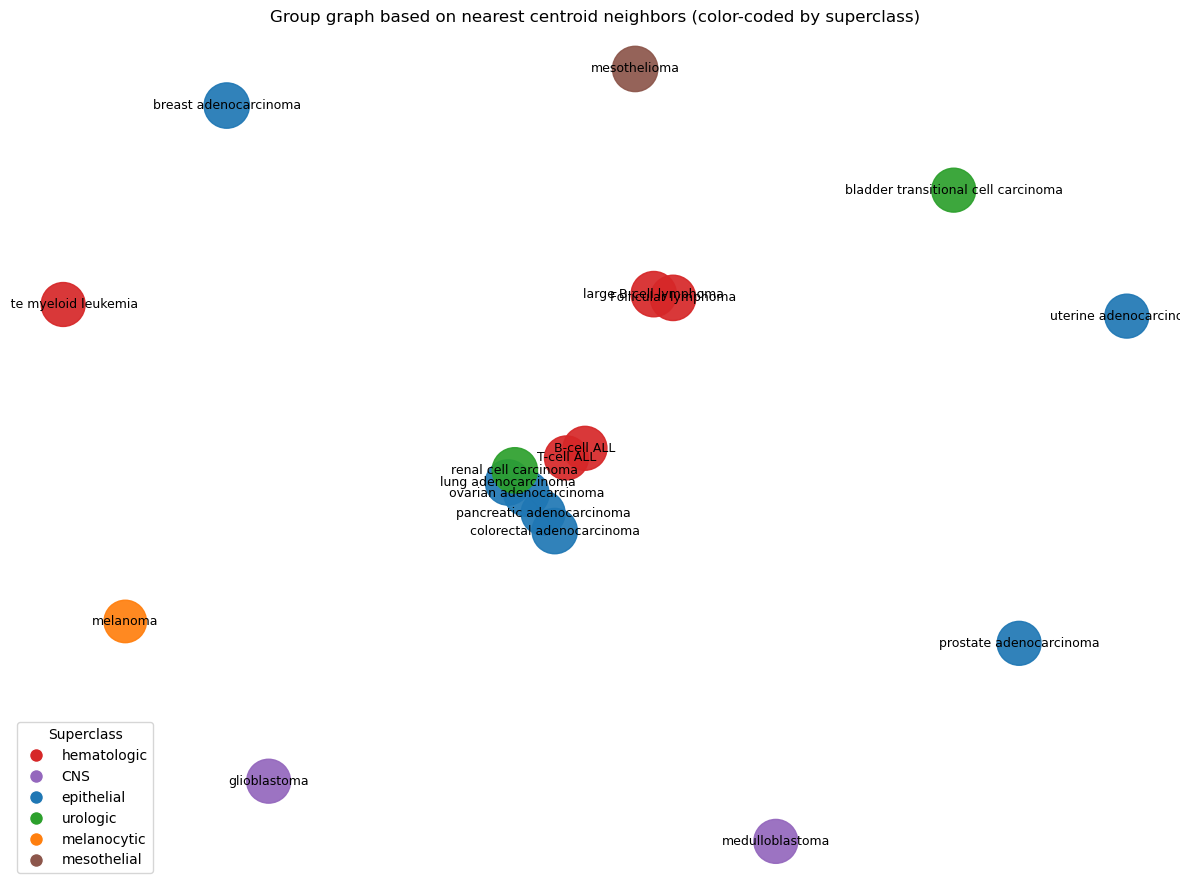

In [31]:
if HAS_NX:
    G = nx.Graph()

    group_meta = (
        merged_summary[["group_label", "superclass", "n_samples"]]
        .drop_duplicates()
        .set_index("group_label")
        .to_dict(orient="index")
    )

    edge_rows = []
    for grp in centroid_dist.index:
        G.add_node(grp, **group_meta.get(grp, {}))

    for grp in centroid_dist.index:
        s = centroid_dist.loc[grp].drop(index=grp).sort_values()
        for neighbor, dist in s.iloc[:N_GRAPH_NEIGHBORS].items():
            edge_rows.append({"group_a": grp, "group_b": neighbor, "distance": float(dist)})

    edge_df = pd.DataFrame(edge_rows).drop_duplicates(subset=["group_a", "group_b"])
    if not edge_df.empty:
        distance_cut = edge_df["distance"].quantile(GRAPH_EDGE_DISTANCE_QUANTILE)
        edge_df = edge_df.loc[edge_df["distance"] <= distance_cut].copy()

    for _, row in edge_df.iterrows():
        G.add_edge(row["group_a"], row["group_b"], weight=row["distance"])

    plt.figure(figsize=(12, 9))
    pos = nx.spring_layout(G, seed=42, weight="weight")

    node_colors = [
        SUPERCLASS_COLORS.get(group_meta.get(node, {}).get("superclass", "other"), SUPERCLASS_COLORS["other"])
        for node in G.nodes()
    ]
    node_sizes = [
        350 + 65 * group_meta.get(node, {}).get("n_samples", 1)
        for node in G.nodes()
    ]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.92)
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, alpha=0.75)

    legend_handles = []
    for key, color in SUPERCLASS_COLORS.items():
        if key in merged_summary["superclass"].unique():
            legend_handles.append(
                plt.Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor=color,
                    markersize=10,
                    label=key,
                )
            )
    if legend_handles:
        plt.legend(handles=legend_handles, title="Superclass", loc="best")

    plt.title("Group graph based on nearest centroid neighbors (color-coded by superclass)")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(NB6_PLOT_DIR / "group_nearest_neighbor_graph_colored.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph_degree_df = pd.DataFrame(
        {"group_label": list(dict(G.degree()).keys()), "graph_degree": list(dict(G.degree()).values())}
    )

    merged_summary = merged_summary.drop(columns=["graph_degree"], errors="ignore").merge(
        graph_degree_df, on="group_label", how="left"
    )
    edge_df.to_csv(NB6_TABLE_DIR / "group_graph_edges_filtered.csv", index=False)
    merged_summary.to_csv(NB6_TABLE_DIR / "group_geometry_plus_graph_summary.csv", index=False)
else:
    print("networkx not installed; skipping graph view.")


## Save final outputs

In [32]:
analysis_df.to_csv(NB6_TABLE_DIR / "analysis_df_used.csv", index=False)
group_geometry_summary.to_csv(NB6_TABLE_DIR / "group_geometry_summary.csv", index=False)
group_geometry_summary.to_csv(NB6_TABLE_DIR / "latent_geometry_metrics_full.csv", index=False)
merged_summary.to_csv(NB6_TABLE_DIR / "final_notebook_06_group_summary.csv", index=False)

short_writeup_lines = [
    "# Notebook 6 short write-up",
    "",
    "## What was measured",
    "- Between-cancer geometry in latent space using centroids, within-group dispersion, local neighborhood mixing, and silhouette-based boundary integrity.",
    "- Notebook 6 now exports a standalone geometry table keyed by dissertation-style comparison labels when available.",
    "",
    "## Strongest descriptive findings",
]

if "superclass" in merged_summary.columns:
    class_counts = (
        merged_summary.groupby("superclass")["group_label"]
        .count()
        .sort_values(ascending=False)
    )
    for superclass, n_groups in class_counts.items():
        short_writeup_lines.append(f"- {superclass}: {n_groups} retained groups in the current analysis.")

if "mean_silhouette" in merged_summary.columns:
    worst = merged_summary.nsmallest(5, "mean_silhouette")[["comparison", "group_label", "mean_silhouette"]]
    best = merged_summary.nlargest(5, "mean_silhouette")[["comparison", "group_label", "mean_silhouette"]]

    short_writeup_lines.append("")
    short_writeup_lines.append("### Lowest silhouette groups")
    for _, row in worst.iterrows():
        label = row["comparison"] if pd.notna(row["comparison"]) else row["group_label"]
        short_writeup_lines.append(f"- {label}: mean silhouette = {row['mean_silhouette']:.3f}")

    short_writeup_lines.append("")
    short_writeup_lines.append("### Highest silhouette groups")
    for _, row in best.iterrows():
        label = row["comparison"] if pd.notna(row["comparison"]) else row["group_label"]
        short_writeup_lines.append(f"- {label}: mean silhouette = {row['mean_silhouette']:.3f}")

if "comparison_source" in merged_summary.columns:
    n_fallback = int((merged_summary["comparison_source"] == "fallback_long").sum())
    short_writeup_lines.append("")
    short_writeup_lines.append("## Mapping notes")
    short_writeup_lines.append(f"- Groups using dissertation short codes: {int((merged_summary['comparison_source'] == 'short_code').sum())}")
    short_writeup_lines.append(f"- Groups using fallback long labels: {n_fallback}")

short_writeup_lines += [
    "",
    "## Cautions",
    "- Notebook 6 is descriptive geometry, not mechanism.",
    "- Negative silhouette or strong cross-group mixing indicates weak boundary integrity for the current labels, not necessarily biological error.",
    "- Legacy entropy/complexity overlays should be used comparatively, not treated as direct causal explanations.",
]

save_markdown_writeup(short_writeup_lines, NB6_TABLE_DIR / "notebook_06_short_writeup.md")

print("Saved analysis table          :", NB6_TABLE_DIR / "analysis_df_used.csv")
print("Saved geometry summary        :", NB6_TABLE_DIR / "group_geometry_summary.csv")
print("Saved full geometry export    :", NB6_TABLE_DIR / "latent_geometry_metrics_full.csv")
print("Saved final summary           :", NB6_TABLE_DIR / "final_notebook_06_group_summary.csv")
print("Saved short write-up          :", NB6_TABLE_DIR / "notebook_06_short_writeup.md")
print("Figure directory              :", NB6_PLOT_DIR)
print("Table directory               :", NB6_TABLE_DIR)


Saved markdown write-up: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\tables\latent\notebook_06\notebook_06_short_writeup.md
Saved analysis table          : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\tables\latent\notebook_06\analysis_df_used.csv
Saved geometry summary        : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\tables\latent\notebook_06\group_geometry_summary.csv
Saved full geometry export    : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\tables\latent\notebook_06\latent_geometry_metrics_full.csv
Saved final summary           : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\output\tables\latent\notebook_06\final_notebook_06_group_summary.csv
Saved short write-up          : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_cur

## Interpretation notes

Keep the interpretive hierarchy explicit:

1. **Boundary integrity first**  
   Start with mean silhouette and same-group neighbor fraction.

2. **Then positional relations**  
   Use nearest-centroid relations and dispersion-normalized separation to see which groups are close in latent space.

3. **Then overlays**  
   Bring in Notebook 5, entropy, and complexity only after the geometric structure is clear.

4. **Then biological interpretation**  
   Ask whether overlap reflects tissue-of-origin continuity, lineage constraint, or convergence onto shared malignant programs.

## Suggested next upgrade

A strong next step is to add a **normal-vs-normal benchmark mode** so that:
- normal-normal distances define tissue baseline separation,
- normal-tumor distances quantify transformation magnitude,
- tumor-tumor distances quantify malignant convergence.
